# Peta laboratorijska vježba - Normalizirajući tokovi

U ovoj laboratorijskoj vježbi koristit ćemo biblioteku normflows koja omogućuje jednostavnu implementaciju normalizirajućih tokova. 
Dokumentacija je dostupna na <a href="https://vincentstimper.github.io/normalizing-flows">linku.</a>

U ovoj laboratorijskoj vježbi proučit će se normalizirajući tokovi, generativni modeli bazirani na toku. Generativni modeli bazirani na toku složeni su od niza invertibilnih transformacija. Za razliku od GAN-ova, oni eksplicitno uče distribuciju podataka $p(x)$ i zbog toga se kao funkcija gubitka koristi negativna log vjerojatnost.

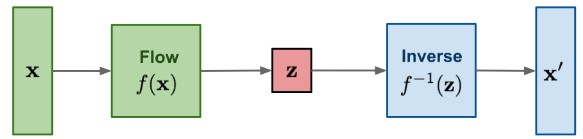

Za razliku od drugih generativnih mreža, svi slojevi su invertibilni, čime se omogućava bijektivno mapiranje između distribucije podataka $p(x)$ i latentne distribucije $p(z)$, koju uobičajeno biramo kao Gaussovu distribuciju. Invertibilno mapiranje podrazumijeva da za svaki uzorak $x$ postoji njemu odgovarajuća latentna varijabla $z$. Zbog toga je odabir arhitekture ograničeniji, ali istovremeno svojstvo invertibilnosti omogućuje NF-ovima da izravno optimiziraju log-vjerojatnost podataka, koja je jednaka
\begin{equation*}
  \log\left(p_X\left(x\right)\right)=\log\left(\left|\det\left(\frac{df}{dx}\right)\right|\right)+\log\left(p_Z\left(f\left(x\right)\right)\right)
\end{equation*}

gdje $f$ predstavlja invertibilno preslikavanje ostvareno neuronskom mrežom, a $p_X(x)$ i $p_Z(z)$ redom distribuciju podataka i latentnih varijabli. 
Izraz unutar logaritma je apsolutna vrijednost determinante Jakobijana $\frac{df}{dx}$.
Ako je $f$ funkcija $N$-dimenzionalnog ulaza i $N$-dimenzionalnog izlaza, onda je njezin Jakobijan jednak:
\begin{equation*}
  \frac{df}{dx} = \begin{bmatrix}
    \frac{df_1}{dx_1} & \frac{df_1}{dx_2} & \cdots& \frac{df_1}{dx_N} \\
    \frac{df_2}{dx_1} & \frac{df_2}{dx_2} & \cdots& \frac{df_2}{dx_N} \\
    \vdots & \vdots & \ddots & \vdots \\
    \frac{df_N}{dx_1} & \frac{df_2}{dx_2} & \cdots& \frac{df_N}{dx_N} \\
\end{bmatrix}.
\end{equation*}
Umjesto jednog preslikavanja $z = f(x)$, može se koristiti i više sekvenca preslikavanja kako bi se dobila složenija distribucija, u tom slučaju je $z_1 = f_1(x)$, i $z_i = f_i(z_{i-1})$, za $i > 2$. Formula za log-vjerojatnost jednostavno se proširuje za taj slučaj:

\begin{equation*}
  \log\left(p_X\left(x\right)\right)=\sum_{i=1}^n\log\left(\left|\det\left(\frac{dz_i}{dz_{i-1}}\right)\right|\right)+\log\left(p_Z\left(f\left(x\right)\right)\right)
\end{equation*}

Izračunavanje determinante Jakobijana općenito nije jednostavno, ali postoje situacije kada se izračun može pojednostavniti.
Primjerice, kada je Jakobijan trokutasta matrica
\begin{equation*}
  \frac{df}{dx} = \begin{bmatrix}
    \frac{df_1}{dx_1} & 0 & \cdots & 0 \\
    \frac{df_2}{dx_1} & \frac{df_2}{dx_2} & \cdots & 0 \\
    \vdots & \vdots & \ddots & \vdots \\
    \frac{df_N}{dx_1} & \frac{df_2}{dx_2} & \cdots & \frac{df_N}{dx_N} \\
\end{bmatrix},
\end{equation*}
njegova determinanta jednaka je umnošku elemenata na dijagonali, pa tada vrijedi pojednostavljenje
\begin{equation*}
  \log\left(\left|\det\left(\frac{df}{dx}\right)\right|\right) 
  = \log \prod_{i=1}^N \left\lvert \frac{df_i}{dx_i} \right \rvert
  = \sum_{i=1}^N \log \left( \left\lvert \frac{df_i}{dx_i} \right \rvert\right).
\end{equation*}

Na slici dolje prikazani su oblici jakobijana koje koriste različiti modeli.

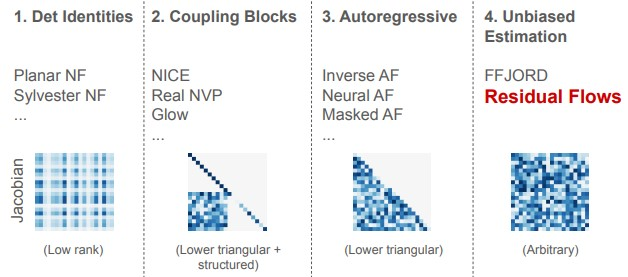

U ovoj vježbi bavit ćemo se modelima Residual Flows i Real NVP.

In [23]:
#!pip install normflows


In [24]:
import torch
import numpy as np
import normflows as nf
import torchvision
from sklearn.datasets import make_moons
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy

%matplotlib inline


# Residual Flows

Residual Flows (ResFlows) su posebna klasa NFa koji pripadaju free-form Jacobovijevoj matrici. ResFlows koriste $f = f_L \circ \ldots \circ f_1$ za invertibilno mapiranje, gdje je svaki sloj $f_l$
invertibilna rezidualna mreža s Lipschitz ograničenjima konstante $\kappa$:

\begin{equation*}
    f_l(\mathbf x)=\mathbf x+g_l(\mathbf x), \quad \mathrm{Lip}(g_l) \le \kappa < 1,
\end{equation*}

gdje je $\mathrm{Lip}(g_l)$ <a href="https://www.wikiwand.com/en/Lipschitz_continuity">Lipschitz konstanta</a> funkcije $g$. 

Više detalja o ResFlows modelima pogledajte na <a href="https://arxiv.org/pdf/1906.02735.pdf">linku.</a>

Napišite argumente multilayer perceptrona tako da je ulaz dimenzije 2, izlaz dimenzije 2, a  postoji po `hidden_units` neurona po jednom sloju toka.
Lipschitzova konstanta neka iznosi 0.9.

In [25]:
def create_residual_nf(num_layers, hidden_units, hidden_layers):
    flows = []
    latent_size = 2

    for i in range(num_layers):
        # Definiramo slojeve: Ulaz (2) -> Skriveni -> Izlaz (2)
        layers = [2] + [hidden_units] * hidden_layers + [2]
        
        param_map = nf.nets.LipschitzMLP(layers, init_zeros=True, lipschitz_const=0.9)

        flows.append(nf.flows.Residual(param_map, reduce_memory=True, reverse=True))
        flows.append(nf.flows.ActNorm(latent_size))

    q0 = nf.distributions.DiagGaussian(2, trainable=False)

    model = nf.NormalizingFlow(q0=q0, flows=flows)
    
    return model


# Real NVP

Real-valued non-volume preserving (Real NVP) se suočava s visoko nelinearnim modelima u visokodimenzionalnim kontinuiranim prostorima kroz najveću vjerojatnost. Kako bi se optimizirala log-vjerojatnost, uvodi se fleksibilnija arhitektura koja omogućuje izračunavanje logaritamske vjerojatnosti na kontinuiranim podatcima. 


\begin{equation*}
\log\left(p_X\left(x\right)\right)=\log\left(p_Z\left(f\left(x\right)\right)\right)+\log\left(\left|\det\left(\frac{\partial f(x)}{\partial x^T}\right)\right|\right)
\end{equation*}

Može se uočiti da se promjena izvršila prilikom računanja determinante Jacobijeve matrice. Promjena arhitekure nalazi se u "affine coupling layer" blok. Glavna ideja je definirati Jacobijevu matricu kao trokutastu matricu na što jednostavniji način kako bi se efektivno mogla izračunati determinanta. Coupling sloj uključuje jednostavnu operaciju skaliranja i pomaka za neki podskup varijabli u trenutnom sloju, dok drugi dio skupa služi za izračunavanje skaliranja i pomaka. Uz $D$ dimenzionalne ulazne varijable $x$, $y$ kao izlaz iz bloka te $d<D$, unaprijedna propagacija računa se izrazom:

\begin{align*}
y_{1:d} &= x_{1:d} \\
y_{d+1:D} &= x_{d+1:D} \odot \exp(s(x_{1:d})) + t(x_{1:d})
\end{align*}

Reverzna propagacija računa se s izrazom:
\begin{align*}
x_{1:d} &= y_{1:d} \\
x_{d+1:D} &= (y_{d+1:D} - t(y_{1:d})) \odot \exp(-s(y_{1:d})) 
\end{align*}

Na sljedećoj slici vizualno su prikazana unaprijedna i reverzna računanja affine coupling sloja.

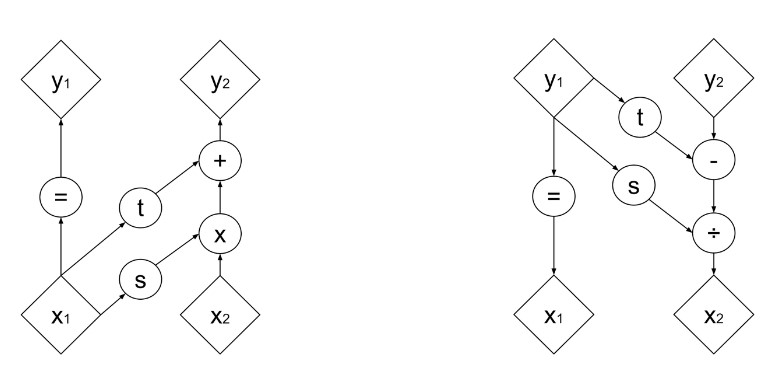

Sada će Jacobijeva matrica poprimiti sljedeći izraz:

\begin{equation}
\frac{\partial y}{\partial x^T} = \left[
\begin{array}{cc}
I_d & 0 \\
\frac{\partial y_{d+1:D}}{\partial x_{1:d}^T} & \text{diag}(\exp[s(x_{1:D})])
\end{array}
\right]
\end{equation} 

Više detalja o Real NVP modelima pogledajte na <a href="https://arxiv.org/abs/1605.08803">linku.</a>

In [26]:
def create_nvp(num_layers, hidden_units):
    flows = []
    
    for i in range(num_layers):
        # Ulaz je 1 dimenzija, izlaz su 2 (scale i shift parametar za drugu dimenziju)
        param_map = nf.nets.MLP([1, hidden_units, hidden_units, 2], init_zeros=True)
        
        flows.append(nf.flows.AffineCouplingBlock(param_map))
        flows.append(nf.flows.Permute(2, mode='swap'))
    
    q0 = nf.distributions.base.DiagGaussian(2, trainable=False)

    model = nf.NormalizingFlow(q0=q0, flows=flows)
    
    return model


# Podešavanje šuma

Pokretanjem koda iscrtavaju se uzorci iz generiranog skupa podataka dobivenog funkcijom <a href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html">`make_moons`</a>.
Crta se $2^{20}$ uzoraka, sa različitim šumom. Na grafovima šum varira od 0.05 do 0.3 sa pomakom od 0.05. 

Šum je standardom devijacija Gaussovog šuma dodana podatcima.


Pitanje: Kako će se ponašati model ako ga učimo na istom skupu podataka, ali sa različitim razinom šuma? Isprobajte treniranje sa dvije vrijednosti šuma (varijabla `NOISE`) i komentirajte rezultate. Dobivene rezultate spremite. 

Odgovor: Povećanjem razine šuma, distribucija podataka postaje "šira" i manje oštra. 

Mali šum: Podaci su koncentrirani u tankim linijama oblika polumjeseca. Model mora naučiti vrlo preciznu i oštru distribuciju gustoće vjerojatnosti. Postoji rizik od overfittinga ako model ima prevelik kapacitet, ali gubitak najboljeg modela je manji. 

Veliki šum: Polumjeseci se stapaju i postaju oblaci točaka. Model će naučiti glađu distribuciju vjerojatnosti. Funkcija gubitka je veća jer je nesigurnost (entropija) podataka veća, tj. distribucija je neodređenija.

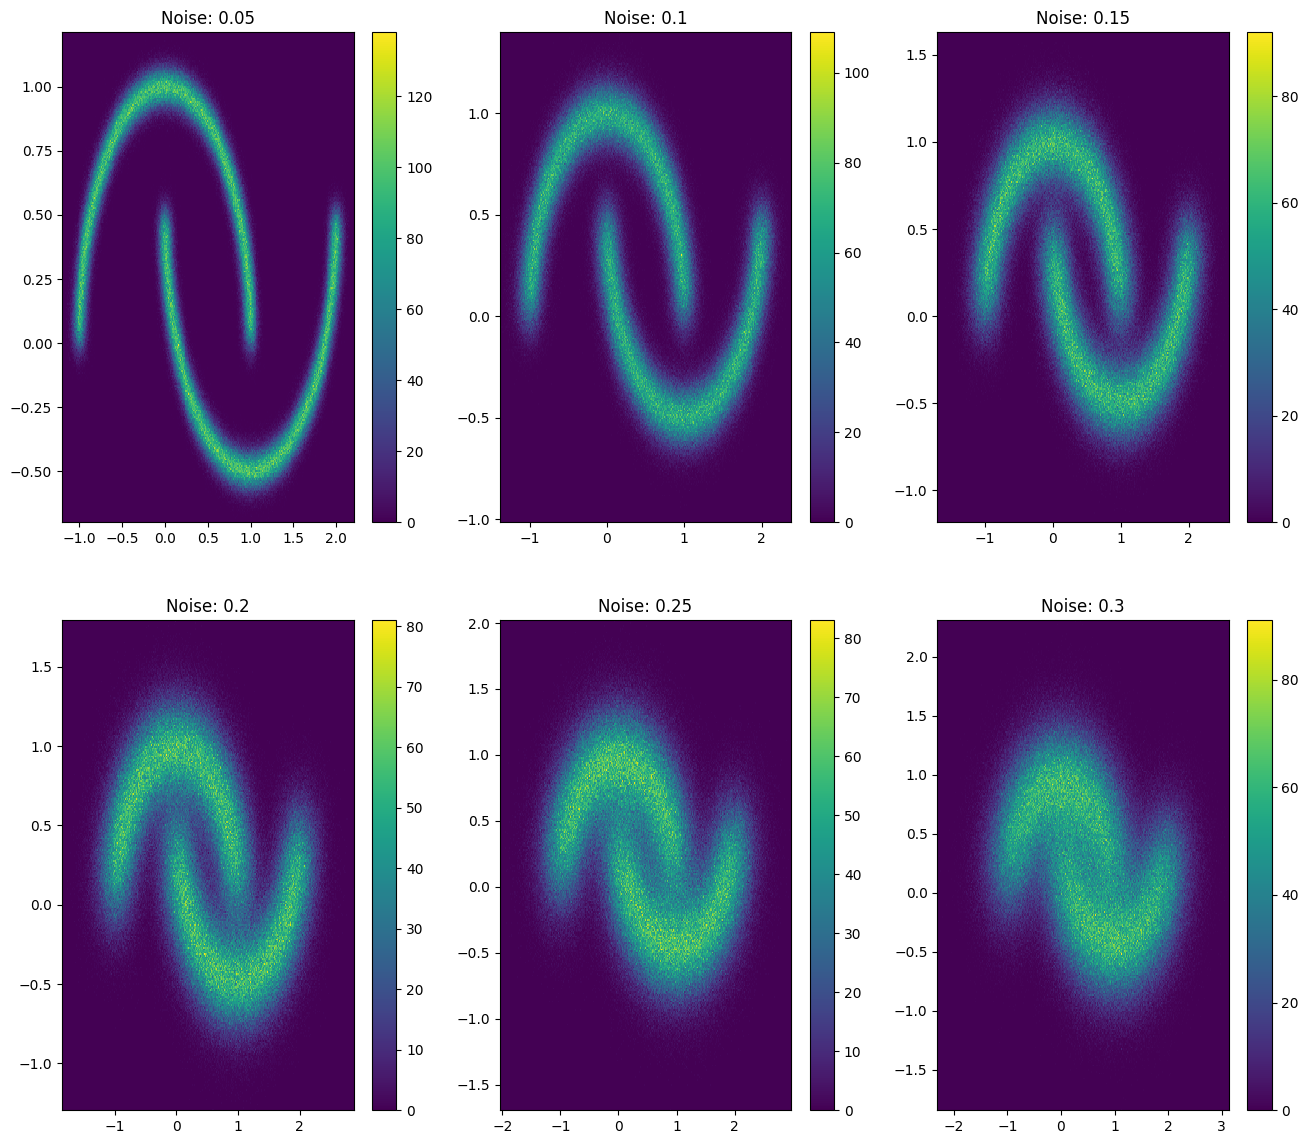

In [27]:
#NOISE = 0.1

plt.figure(figsize=(16, 14))


for i, noise in enumerate([0.05, 0.1, 0.15, 0.2, 0.25, 0.3]):
    x_np, _ = make_moons(2 ** 20, noise=noise)
    plt.subplot(2, 3, i + 1)
    plt.hist2d(x_np[:, 0], x_np[:, 1], bins=300)
    plt.colorbar()
    plt.title(f'Noise: {noise}')
plt.show()


In [28]:
def draw_model_output(model):

    grid_size = 100

    xx, yy = torch.meshgrid(torch.linspace(-1.5, 2.5, grid_size), torch.linspace(-2, 2, grid_size))
    zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
    zz = zz.to('cpu')

    model.eval()
    log_prob = model.log_prob(zz).to('cpu').view(grid_size, grid_size)

    model.train()
    prob = torch.exp(log_prob)
    prob[torch.isnan(prob)] = 0

    plt.figure(figsize=(6, 6))
    plt.pcolormesh(xx, yy, prob.data.numpy())
    plt.colorbar()
    plt.show()


Isprobajte oba modela mijenjanjem varijable `model_type`. Za svaki model isprobajte dvije do tri kombinacije sa brojem slojeva, brojem skrivenih neurona i brojem skrivenih slojeva. Spremite izlaze svi različitih modela nakon treninga, kako bi se mogli vidjeti rezultate na laboratorijskoj vježbi.
Prokomentirajte rezultate.

Nacrtani graf prikazuje početni izlaz modela prije treniranja. Ona će se mijenjati tijekom treniranja i pokušati naučiti Moons distribuciju.

In [29]:
grid_size = 100

xx, yy = torch.meshgrid(torch.linspace(-1.5, 2.5, grid_size), torch.linspace(-2, 2, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)


In [30]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
'''
model_type = 'nvp'

if model_type == 'residual':

    num_layers = 16
    hidden_units = 128
    hidden_layers = 3

    model = create_residual_nf(num_layers=num_layers, hidden_units=hidden_units, hidden_layers=hidden_layers)
    model.to(DEVICE)

if model_type == 'nvp':
    num_layers = 16
    hidden_units = 128

    model = create_nvp(num_layers=num_layers, hidden_units=hidden_units)
    model.to(DEVICE)
    
zz = zz.to(DEVICE)

draw_model_output(model)
'''


"\nmodel_type = 'nvp'\n\nif model_type == 'residual':\n\n    num_layers = 16\n    hidden_units = 128\n    hidden_layers = 3\n\n    model = create_residual_nf(num_layers=num_layers, hidden_units=hidden_units, hidden_layers=hidden_layers)\n    model.to(DEVICE)\n\nif model_type == 'nvp':\n    num_layers = 16\n    hidden_units = 128\n\n    model = create_nvp(num_layers=num_layers, hidden_units=hidden_units)\n    model.to(DEVICE)\n    \nzz = zz.to(DEVICE)\n\ndraw_model_output(model)\n"

# Funkcija za treniranje modela

U svakoj epohi uzorukuje se `num_samples` uzoraka, te se računa loss preko KL divergencije. Svakih `show_epoch` se pokazuje `zz` izlaz modela koji bi se trebao kroz epohe prilagođavati distribuciji zadanog skupa podataka. 
Neka funkcija vraća: 
  - zadnje naučeni model
  - model s najmanjim gubitkom
  - vrijednosti funkcije gubitka kroz sve epohe

In [ ]:
def train_nf(model, epochs, model_type, optimizer, num_samples=2 ** 9, show_epoch=200, noise_level=0.1):
    loss_array = []
    
    smallest_loss = np.inf
    best_model = None
    model.train()
    
    for epoch in tqdm(range(epochs)):
        optimizer.zero_grad()
        
        x_np, _ = make_moons(num_samples, noise=noise_level)
        x = torch.tensor(x_np).float().to(DEVICE)
        
        loss = model.forward_kld(x)
        
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()
        
            loss_array.append(loss.item())
            
            if loss.item() < smallest_loss:
                smallest_loss = loss.item()
                best_model = copy.deepcopy(model)
                
        if model_type == 'residual':
            nf.utils.update_lipschitz(model, 50)
            
        if (epoch + 1) % show_epoch == 0:
            model.eval()
            log_prob = model.log_prob(zz.to(DEVICE))
            
            model.train()
            prob = torch.exp(log_prob.to('cpu').view(100, 100))
            prob[torch.isnan(prob)] = 0

            plt.figure(figsize=(6, 6))
            plt.pcolormesh(xx, yy, prob.data.numpy())
            plt.show()

    return model, best_model, loss_array



--- Training: nvp_L8_U64_N0.1 ---


  0%|          | 0/5000 [00:00<?, ?it/s]

 30%|██▉       | 1498/5000 [00:40<01:30, 38.80it/s]

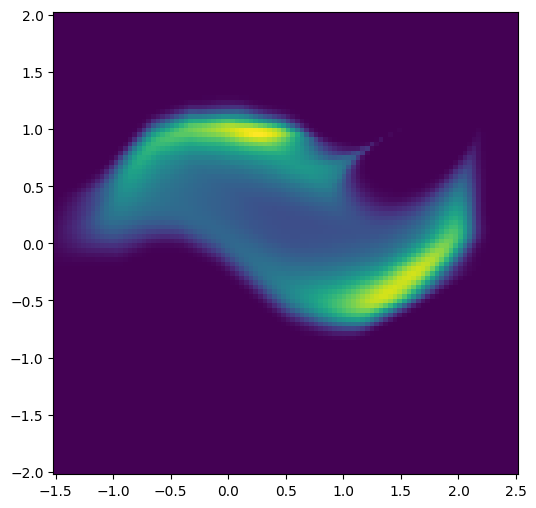

 60%|█████▉    | 2996/5000 [01:16<00:47, 42.17it/s]

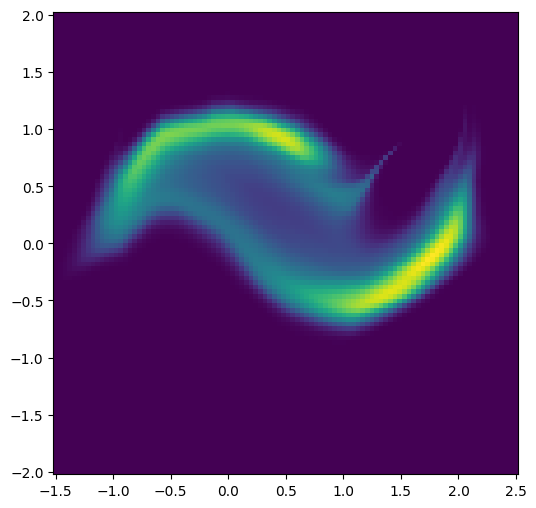

 90%|████████▉ | 4497/5000 [01:53<00:12, 41.62it/s]

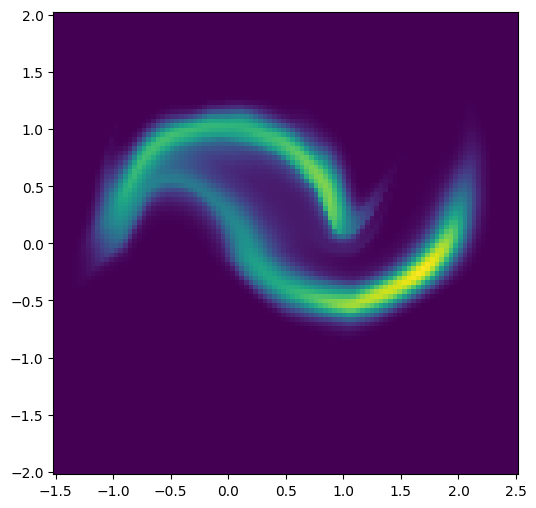

100%|██████████| 5000/5000 [02:05<00:00, 39.73it/s]


Final Loss for nvp_L8_U64: 1.0981


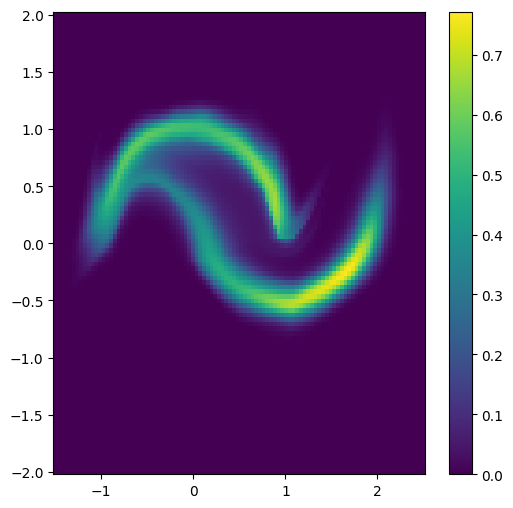


--- Training: nvp_L16_U128_N0.1 ---


 30%|██▉       | 1497/5000 [01:19<02:53, 20.18it/s]

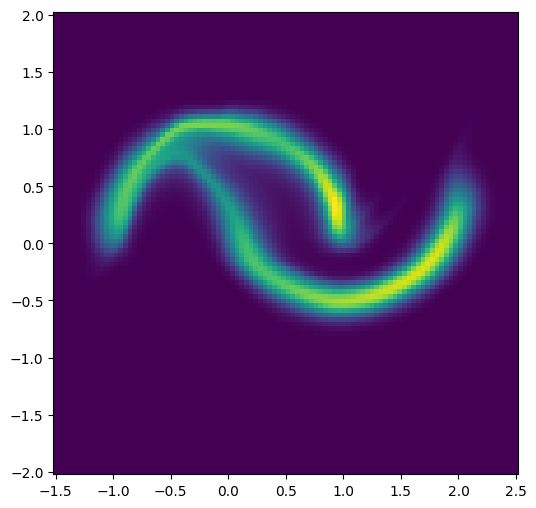

 60%|█████▉    | 2998/5000 [02:38<01:59, 16.78it/s]

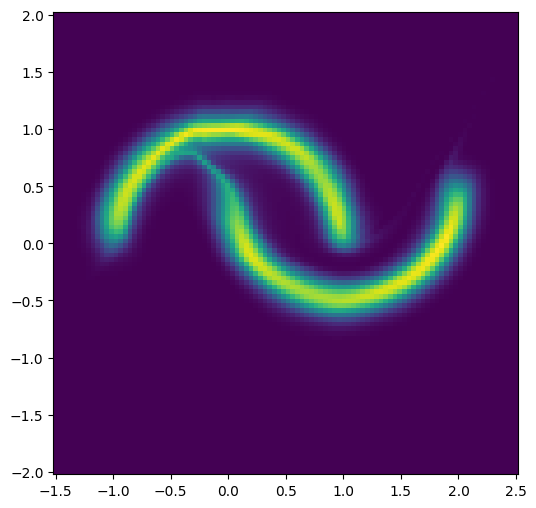

 90%|████████▉ | 4497/5000 [03:56<00:28, 17.48it/s]

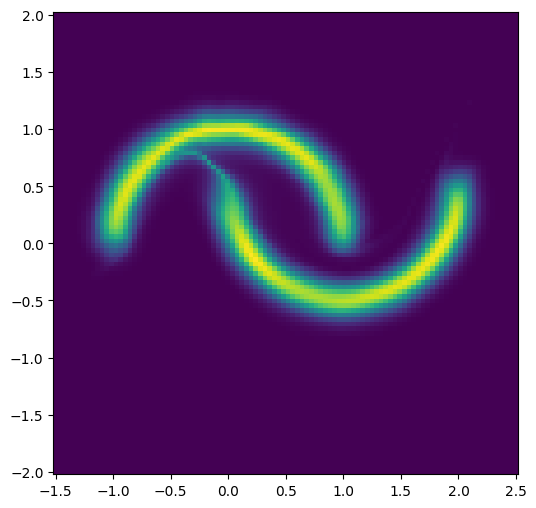

100%|██████████| 5000/5000 [04:22<00:00, 19.05it/s]


Final Loss for nvp_L16_U128: 1.0302


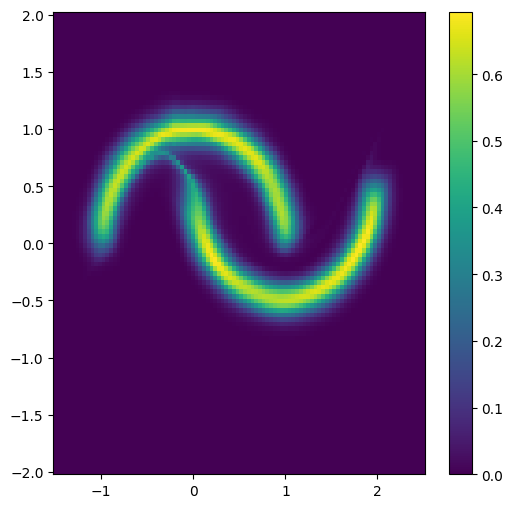


--- Training: residual_L8_U64_N0.1 ---


 30%|██▉       | 1499/5000 [05:46<13:24,  4.35it/s]

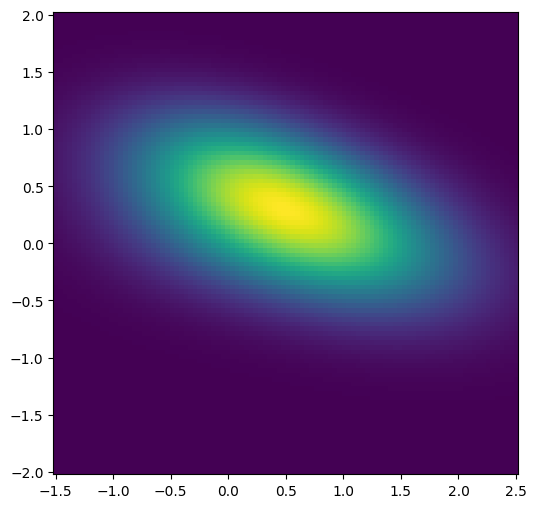

 60%|█████▉    | 2999/5000 [11:29<07:37,  4.37it/s]

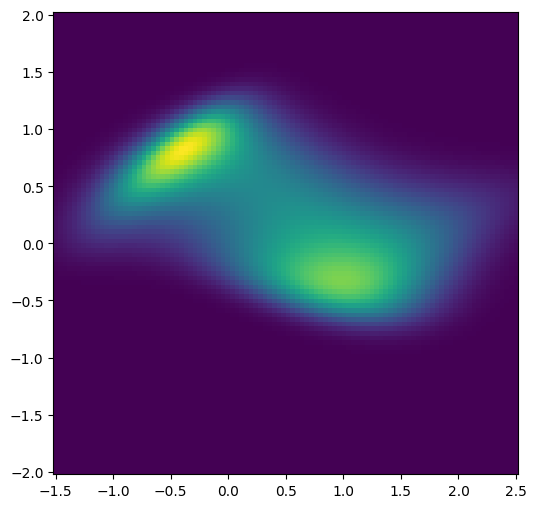

 90%|████████▉ | 4499/5000 [17:20<01:57,  4.28it/s]

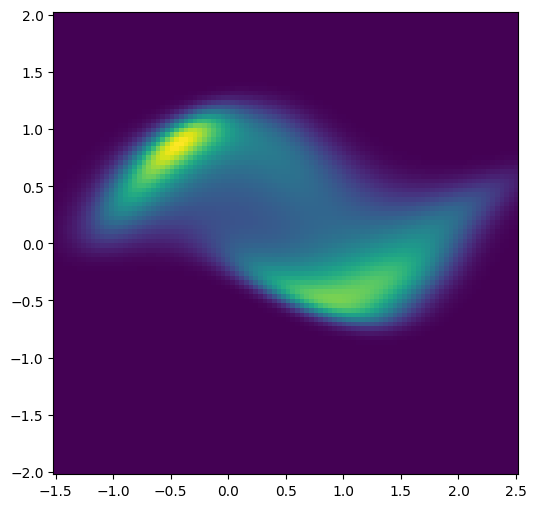

100%|██████████| 5000/5000 [19:15<00:00,  4.33it/s]


Final Loss for residual_L8_U64: 2.0481


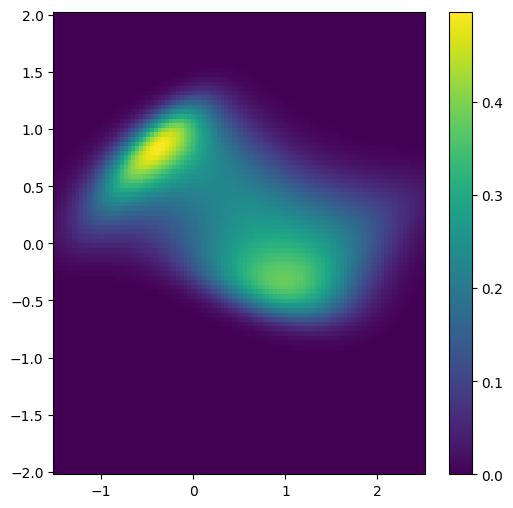


--- Training: residual_L16_U128_N0.25 ---


 30%|██▉       | 1499/5000 [17:01<39:50,  1.46it/s]

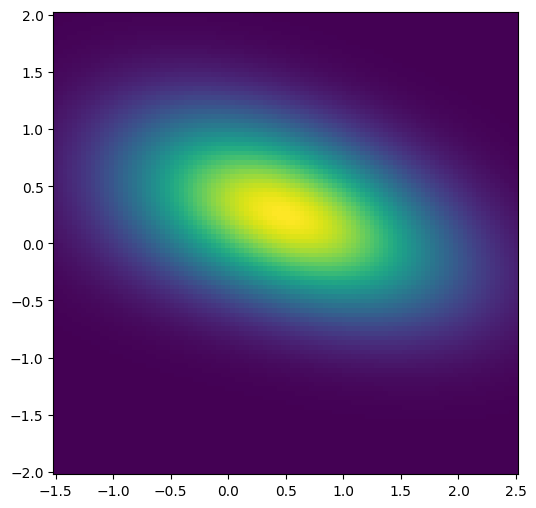

 60%|█████▉    | 2999/5000 [34:22<23:12,  1.44it/s]  

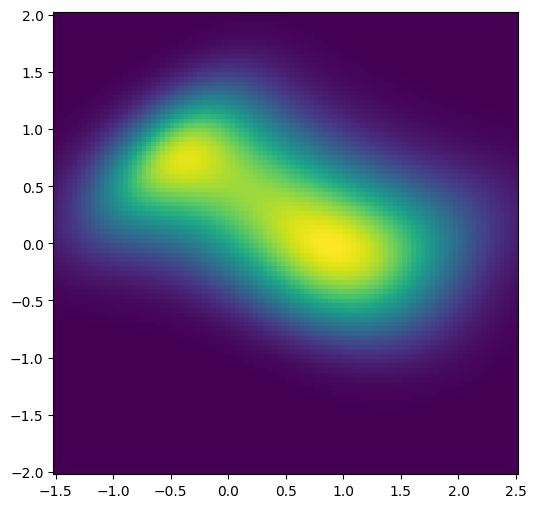

 90%|████████▉ | 4499/5000 [51:52<06:08,  1.36it/s]

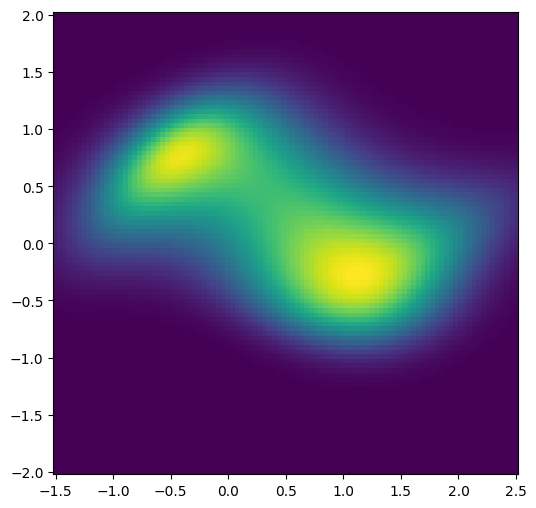

100%|██████████| 5000/5000 [57:42<00:00,  1.44it/s]


Final Loss for residual_L16_U128: 1.9272


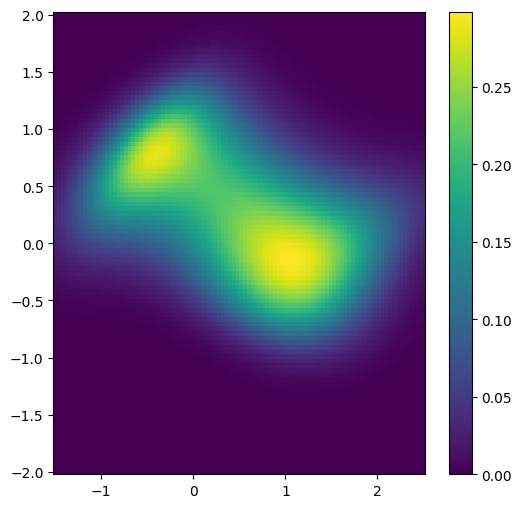

In [32]:
configs = [
    {'type': 'nvp', 'layers': 8, 'units': 64, 'noise': 0.1},
    {'type': 'nvp', 'layers': 16, 'units': 128, 'noise': 0.1},
    {'type': 'residual', 'layers': 8, 'units': 64, 'h_layers': 2, 'noise': 0.1},
    {'type': 'residual', 'layers': 16, 'units': 128, 'h_layers': 3, 'noise': 0.25}
]

results = {}

for cfg in configs:
    m_type = cfg['type']
    n_val = cfg['noise']
    config_name = f"{m_type}_L{cfg['layers']}_U{cfg['units']}_N{n_val}"

    print(f"\n--- Training: {config_name} ---")
    
    if m_type == 'nvp':
        model = create_nvp(num_layers=cfg['layers'], hidden_units=cfg['units'])
    else:
        model = create_residual_nf(num_layers=cfg['layers'], hidden_units=cfg['units'], hidden_layers=cfg['h_layers'])
    
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

    epochs = 5000
    show_epochs = 1500
    
    model, best_model, loss_arr = train_nf(model, epochs, m_type, optimizer, show_epoch=show_epochs, noise_level=n_val)
    
    config_name = f"{m_type}_L{cfg['layers']}_U{cfg['units']}"
    results[config_name] = {
        'best_model': best_model,
        'loss_array': loss_arr,
        'noise': n_val
    }
    
    print(f"Final Loss for {config_name}: {loss_arr[-1]:.4f}")
    draw_model_output(best_model)


**Zadatak**

Prokomentirajte izgled funckije gubitka. `loss_noise` postavite na vrijednost oko 30, kako bi vam graf bio bez outliera. Ukoliko treba probajte prikaz sa drugom vrijednosti ovisno o outlierima.

Odgovor : 

*Konvergencija: Residual vs. Real NVP*

Složenost optimizacije: 

 - Real NVP (narančasta i plava linija) koristi trokutasti Jakobijan koji omogućuje vrlo direktan i brz izračun gradijenata. Vidimo da ovi modeli vrlo brzo padaju na niski loss već u prvih 500-1000 epoha.

 Lipschitzovo ograničenje: 
 
 - Residual Flows (zelena i crvena linija) moraju zadovoljavati Lipschitz uvjet kako bi ostali invertibilni. To strogo ograničenje težina mreže značajno usporava učenje jer sprječava model da radi "agresivne" skokove u prostoru parametara.

 - Potreba za više epoha: Zelena linija (residual_L8) pokazuje vrlo blag i linearan pad. Ona se na 5000 epoha još uvijek nije potpuno stabilizirala (nije ušla u pravi "plato"), što potvrđuje da bi ovom tipu arhitekture vjerojatno trebalo 10.000 ili više epoha da dosegne razinu preciznosti koju NVP postigne puno brže.

Real NVP je superioran u brzini konvergencije na jednostavnim 2D problemima zbog jednostavne strukture Jakobijana.

Residual Flow je stabilniji (manje oscilacija), ali zahtijeva znatno više vremena/epoha za učenje zbog Lipschitzovih ograničenja.

Razina šuma direktno određuje donju granicu (baseline) funkcije gubitka – veći šum neizbježno znači viši gubitak.



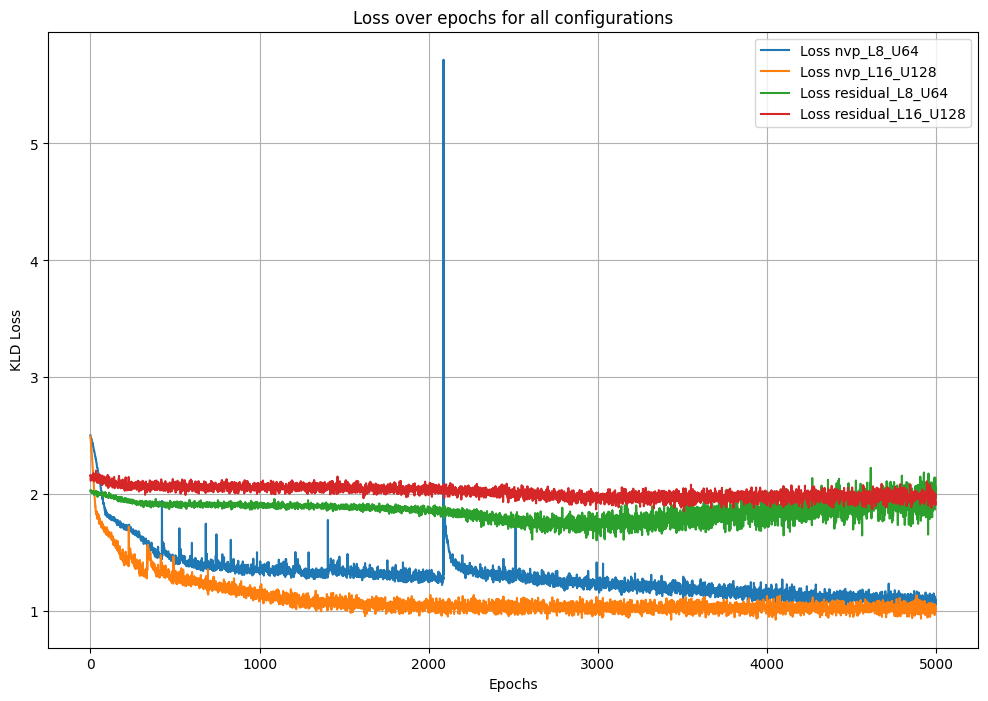

In [33]:
plt.figure(figsize=(12, 8))
loss_noise = 30

for config_name, data in results.items():
    loss_array = np.array(data['loss_array'])
    filtered_loss = loss_array[loss_array < loss_noise]
    
    plt.plot(filtered_loss, label=f'Loss {config_name}')

plt.legend()
plt.grid(True)
plt.title('Loss over epochs for all configurations')
plt.xlabel('Epochs')
plt.ylabel('KLD Loss')
plt.show()


**Zadatak**

Prokomentirajte razliku između ResidualFlowa i Real NVP modela. Ispišite vrijednost funkcije gubitka za oba modela.

Odgovor: 

Real NVP: 
 - Dijeli ulaz na dva dijela; jedan dio transformira drugi pomoću skaliranja i pomaka.
 - Jakobijan: Trokutasta matrica. Determinanta je produkt elemenata na dijagonali (vrlo brzo).
 - Invertibilnost: Analitička i brza (samo promijenimo predznake u transformaciji).
 - Fleksibilnost: Ograničena (pola vektora se ne mijenja u jednom sloju).

Residual Flows: 
 - Koristi rezidualne veze uz Lipschitz ograničenja.
 - Jakobijan: Free-form (opća matrica). Determinanta se procjenjuje stohastički (sporije).
 - Invertibilnost: Iterativna (zahtijeva Banachov teorem o fiksnoj točki, sporije i otežava optimizaciju, Lipschitz konstanta < 1)
 - Fleksibilnost: Visoka (može naučiti vrlo kompleksne i "organske" oblike), ali zahtjeva više slojeva za istu ekspresivnost i osjetljiviji na hiperparametre.
 - Lipschitzova konstanta: Ako je veća od 1, transformacija prestaje biti invertibilna (mapiranje više nije bijektivno), što ruši cijelu teoriju NF-a.

Utjecaj hiperparametara:
- Povećanje broja slojeva - Povećava se ekspresivnost modela. Model može naučiti složenije transformacije (oštrije rubove, kompleksnije zavoje). Teže treniranje, opasnost od nestabilnih gradijenata i duže vrijeme izvođenja.
- Povećanje broja skrivenih neurona - Bolje modeliranje lokalnih varijacija unutar distribucije. Prevelik broj može dovesti do overfittinga na malim skupovima podataka.
- Promjena šuma u podacima - Šum predstavlja aleatornu neodređenost. Veći šum znači da su "polumjeseci" deblji i da se preklapaju. Što je šum veći, to će minimalni gubitak biti veći. To je zato što je distribucija s više šuma "razmazanija" (ima veću entropiju), pa je gustoća vjerojatnosti u bilo kojoj točki manja. 

RESULTS FOR: nvp_L8_U64
Test Loss (KLD): 1.0904


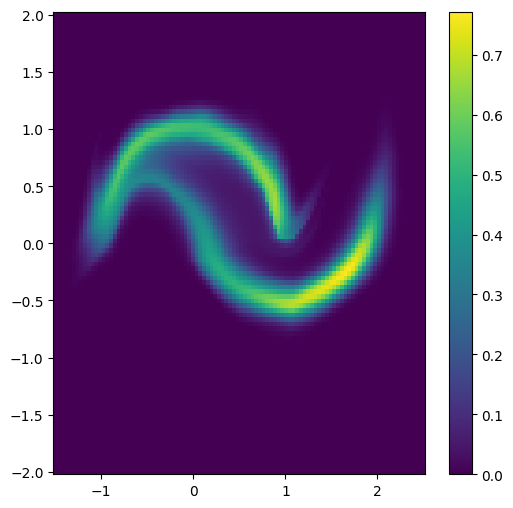

RESULTS FOR: nvp_L16_U128
Test Loss (KLD): 1.0143


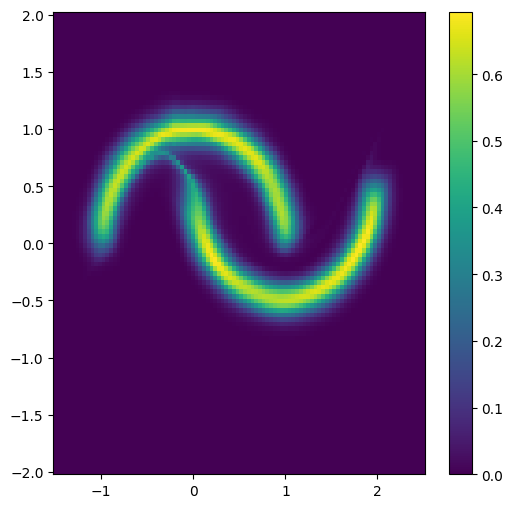

RESULTS FOR: residual_L8_U64
Test Loss (KLD): 1.5951


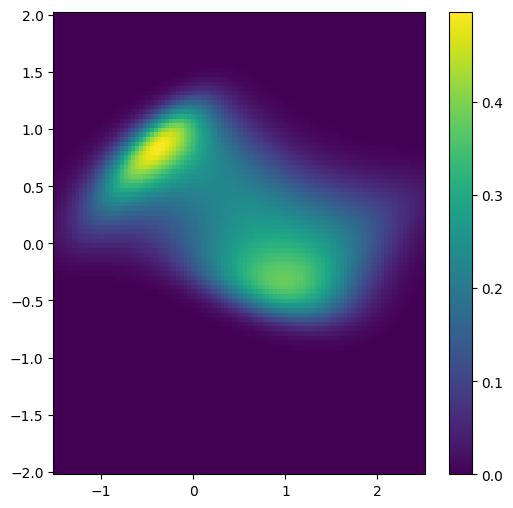

RESULTS FOR: residual_L16_U128
Test Loss (KLD): 1.9447


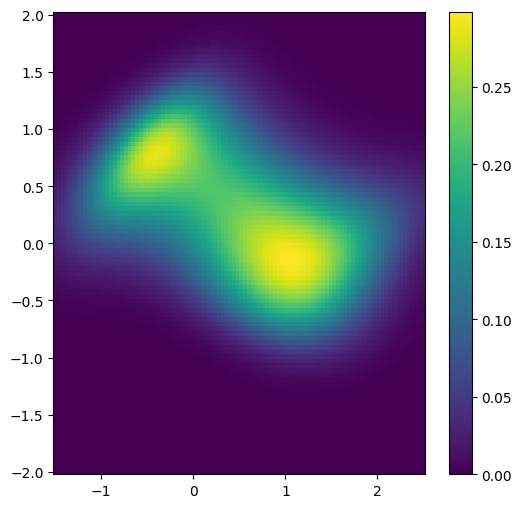

In [34]:
n_samples = 2**11


for config_name, data in results.items():
    model = data['best_model']
    model.eval()

    x_np, _ = make_moons(n_samples, noise=data['noise'])
    x_test = torch.tensor(x_np).float().to(DEVICE)

    with torch.no_grad():
        loss_val = model.forward_kld(x_test)
    
    print(f"{'='*30}")
    print(f"RESULTS FOR: {config_name}")
    print(f"Test Loss (KLD): {loss_val.item():.4f}")
    print(f"{'='*30}")

    draw_model_output(model)


Općenito:

- Jakobijan je bitan - jer nam on govori kako se "volumen" prostora mijenja tijekom transformacije. Bez determinante Jakobijana, ne bismo mogli osigurati da integral gustoće vjerojatnosti ostane 1.

- Permute i Reverse slojevi (Real NVP) - Jedan sloj mijenja samo pola varijabli. Permutacija osigurava da se u sljedećem sloju mijenjaju one varijable koje su u prethodnom ostale iste, omogućujući miješanje informacija.

- NF vs GAN: NF daje egzaktnu procjenu gustoće, nema problema s "mode collapse" efektom i lako se invertira (možemo točno dobiti latentni vektor z za bilo koji x).

- NF vs VAE: NF računa egzaktnu log-vjerojatnost p(x), dok VAE računa samo donju granicu (ELBO) jer mu je integral u nazivniku matematički nerješiv. Kod NF-a, latentna varijabla z ima istu dimenzionalnost kao i ulaz x. Kod VAE-a, latentni prostor je obično puno manji (kompresija/bottleneck). NF koristi determinističko, bijektivno (1-na-1) mapiranje. VAE je stohastičan (enkoder daje parametre distribucije, a ne fiksnu točku).

- NF vs Diffusion: NF generira uzorak u jednom unaprijednom prolazu kroz mrežu. Difuzijski modeli su iterativni – kreću od čistog šuma i postupno ga uklanjaju kroz stotine koraka (što je puno sporije). NF se oslanja na teorem o zamjeni varijabli i determinantu Jakobijana. Difuzijski modeli se oslanjaju na stohastičke diferencijalne jednadžbe i predviđanje šuma. Kod NF-a svaki sloj mora biti invertibilan. Kod Diffusion modela, mreža koja predviđa šum može biti bilo kakva, što daje veću slobodu u dizajnu (ovo vrijedi i za druge mreže). 